In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = "results/{0}_fig7_rho_sub_critical_test_3.p"
#N_range = [int(n) for n in np.geomspace(1e5, 3e6, 10)]
N_range = [ 100000,  145923,  212936, 310723]
num_ensambles = 1024
M = np.empty((len(N_range), num_ensambles))

In [27]:
for n in range(num_ensambles):
    with open(path.format(n), "rb") as f:
        mags = pickle.load(f)
        print(mags)
        for N in range(len(N_range)):
            m = mags[N]
            M[N,n] = m

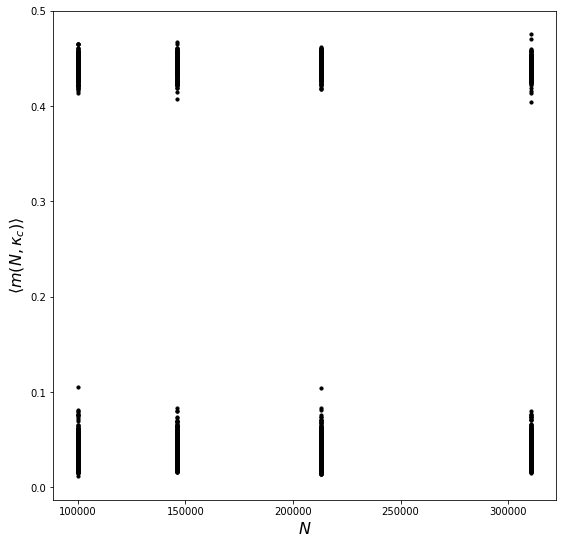

In [113]:
plt.figure(figsize=(9,9))
for n in range(num_ensambles):
    plt.scatter(N_range, M[:, n], s=10,c='k')
plt.xlabel(r'$N$', fontsize=16)
plt.ylabel(r'$\langle m(N, \kappa_c)\rangle$', fontsize=16)
plt.show()

In [21]:
pairs = []

for N in range(len(N_range)):
    ms = M[N]
    md = ms[ms <=0.25]
    if md.size >= ms.size//4:
        pairs.append([N_range[N], 0.0559263564072972-np.mean(md), np.std(md)])
        
pairs = np.array(pairs)

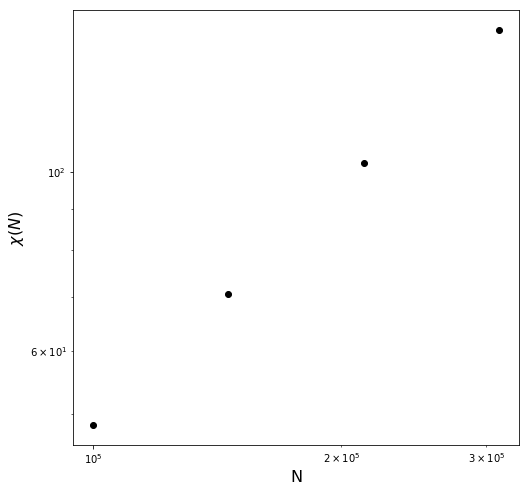

In [19]:
pairs = []

for N in range(len(N_range)):
    ms = M[N]
    md = ms[ms <=0.25]
    if md.size >= 0:#ms.size//4:
        pairs.append([N_range[N], N_range[N]*(np.mean(md**2)-np.mean(md)**2)])
        
pairs = np.array(pairs)
plt.figure(figsize=(8,8))
plt.loglog(*pairs[:,:2].T, 'ko')
plt.xlabel('N', fontsize=16)
plt.ylabel(r'$\chi (N)$', fontsize=16)
plt.show()

In [20]:
z = np.polyfit(np.log(pairs[:, 0]), np.log(pairs[:, 1]), 1)
print(z)
p = np.poly1d(z)

[ 0.99682686 -7.59661889]


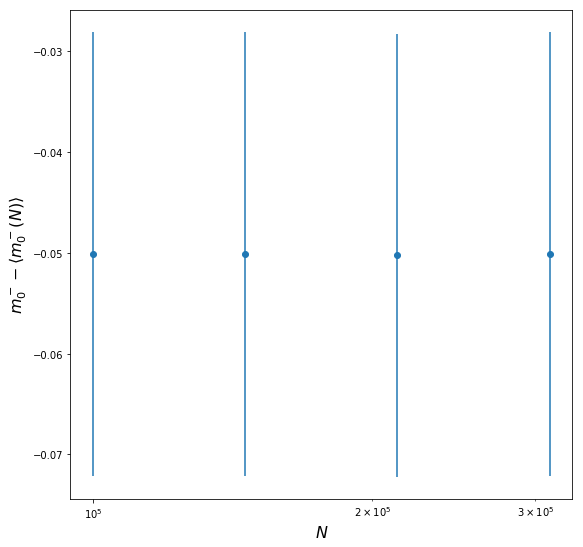

In [22]:
plt.figure(figsize=(9,9))
plt.errorbar(*pairs[:, :2].T, yerr=pairs[:, 2], fmt='o')
#plt.plot(pairs[:, 0], p(np.log(pairs[:, 0])))
plt.ylabel(r'$m_0^--\langle m_0^-(N)\rangle$', fontsize=16)
plt.xlabel(r'$N$', fontsize=16)
plt.xscale('log')
#plt.yscale('log')
plt.show()

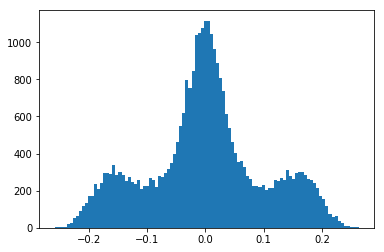

In [15]:
plt.hist(M[3,:]-M[2,:], bins=100)
plt.show()

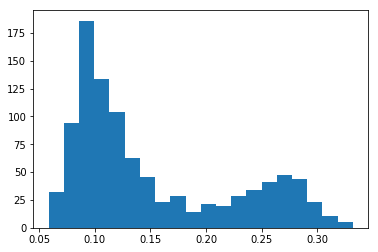

In [26]:
plt.hist(M[0,:1000], bins=20)
plt.show()